# 06: Model Error Analysis

This notebook examines the prediction errors produced by the baseline sentiment models.

Main inputs from Notebook 05:

```text
combined_tagged_reviews_model_ready.csv
binary_sentiment_predictions.csv
multiclass_sentiment_predictions.csv
baseline_binary_sentiment_tfidf_logreg.joblib
```

The analysis focuses on:

1. evaluating binary model errors
2. evaluating multiclass model errors
3. identifying the sentiment classes that are hardest to predict
4. inspecting the review patterns behind wrong predictions
5. relating model errors to manual categories such as `Mixed`, `Meme`, `Low Information`, `Mourning`, and `Soft Mismatch`
6. exporting error examples for the dashboard and project report
7. summarizing the findings without overclaiming

> The focus here is **interpretation**, not forcing a higher accuracy score.

## 0. Why Error Analysis Matters

The binary model performs reasonably well for clear `Positive` and `Negative` reviews.

The multiclass task is more difficult because Steam reviews often contain:

```text
Mixed sentiment
Meme / joke review
Low-information text
Positive review with complaints
Update backlash with nostalgia
Sarcasm / community defense
```

The main question for this notebook is:

```text
Where does the model fail, and what does that failure tell us about Steam review behavior?
```

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

DATA_PROCESSED = Path("../data/processed")

pd.set_option("display.max_colwidth", 300)
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Configure Input and Output Files

The notebook reads the model outputs directly from the cleaned `data/processed/` directory.

In [ ]:
MODEL_READY_PATH = DATA_PROCESSED / "combined_tagged_reviews_model_ready.csv"
BINARY_PRED_PATH = DATA_PROCESSED / "binary_sentiment_predictions.csv"
MULTICLASS_PRED_PATH = DATA_PROCESSED / "multiclass_sentiment_predictions.csv"

BINARY_WRONG_OUTPUT_PATH = DATA_PROCESSED / "binary_wrong_predictions_enriched.csv"
MULTICLASS_WRONG_OUTPUT_PATH = DATA_PROCESSED / "multiclass_wrong_predictions_enriched.csv"
ERROR_SUMMARY_OUTPUT_PATH = DATA_PROCESSED / "model_error_analysis_summary.csv"
DASHBOARD_EXAMPLES_OUTPUT_PATH = DATA_PROCESSED / "dashboard_error_examples.csv"

required_paths = [
    MODEL_READY_PATH,
    MULTICLASS_PRED_PATH
]

missing_paths = [
    path for path in required_paths
    if not path.exists()
]

if missing_paths:
    missing_text = "\n".join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        "Required model output files were not found:\n"
        f"{missing_text}"
    )

print("Model-ready dataset:", MODEL_READY_PATH)
print("Binary predictions:", BINARY_PRED_PATH)
print("Multiclass predictions:", MULTICLASS_PRED_PATH)
print("Processed data directory:", DATA_PROCESSED)

Model-ready dataset: ..\data\processed\combined_tagged_reviews_model_ready.csv
Binary predictions: ..\data\processed\binary_sentiment_predictions.csv
Multiclass predictions: ..\data\processed\multiclass_sentiment_predictions.csv
Processed output dir: ..\data\processed


## 2. Load Model Outputs

In [ ]:
model_df = pd.read_csv(MODEL_READY_PATH)
multiclass_pred = pd.read_csv(MULTICLASS_PRED_PATH)

if BINARY_PRED_PATH.exists():
    binary_pred = pd.read_csv(BINARY_PRED_PATH)
else:
    binary_pred = None

print("Model-ready shape:", model_df.shape)
print("Multiclass predictions shape:", multiclass_pred.shape)

if binary_pred is not None:
    print("Binary predictions shape:", binary_pred.shape)

display(model_df.head())
display(multiclass_pred.head())

if binary_pred is not None:
    display(binary_pred.head())

Model-ready shape: (171, 44)
Multiclass predictions shape: (43, 3)
Binary predictions shape: (30, 3)


,game_title,review_date,recommendation,playtime_raw,playtime_hours,playtime_segment,helpful_count,funny_count,weighted_vote_score,comment_count,...,is_mourning_refined,is_mismatch_candidate,review_category,review_dedup_key,char_count,log_playtime,mismatch_type_recomputed,is_mismatch_or_ambiguous_target,binary_sentiment_target,multiclass_sentiment_target
0,Phasmophobia,Posted: 12 May,Not Recommended,NaN,77.1,Regular,0,0,NaN,NaN,...,False,False,Update Backlash; Sarcasm / Bug Complaint,rushed out a buggy and broken update so they could do an alan wake (2) collab. marvelous.,89,4.357990,Aligned Negative,False,Negative,Negative
1,Phasmophobia,Posted: 12 May,Not Recommended,NaN,23.5,Casual,3,0,NaN,NaN,...,False,False,Update Backlash; Mourning-lite,the latest update has ruined the experience for me ( bendy back gone),69,3.198673,Aligned Negative,False,Negative,Negative
2,Phasmophobia,Posted: May 12,Not Recommended,NaN,65.4,Regular,4,0,NaN,NaN,...,False,False,Update Backlash; Developer Criticism,this last update was a mess. it's been on the roadmap since 2022 yet the devs keep saying it was rushed at every turn. an update that is a flawed mess of so called features. if you like awful ai like animations and a dev team that will lie about the poor quality of updates and then deflect when ...,848,4.195697,Aligned Negative,False,Negative,Negative
3,Phasmophobia,Posted: May 12,Not Recommended,NaN,470.5,Hardcore,0,0,NaN,NaN,...,False,False,Update Backlash; Bug / Gameplay Degradation,"tl;dr don't get it yet character customization added animations that made it so sluggish i have played this game for many hours, maybe not as much as some of the community but still enough to enjoy my time with this game, i have been through the janky times of when the game first came out and i ...",813,6.155919,Aligned Negative,False,Negative,Negative
4,Phasmophobia,Posted: May 12,Not Recommended,NaN,476.6,Hardcore,3,0,NaN,NaN,...,False,False,Mourning; Update Backlash,"i used to really love playing this game, but it seems the devs have just been making questionable decisions ever since the item update. rather than rework maps that no one likes, like school or prison, they reworked a beloved map. i actually like new tanglewood, but it feels like they only did t...",2261,6.168774,Aligned Negative,False,Negative,Negative


,analysis_review,actual_label,predicted_label
0,"Absolutely loved this game for years, enough that I rebought the game after losing my steam account, always came back time after time. Saw all the changes to the lobbies, maps, equipment, progression, ghosts, etc... and stuck with it. But I'm done, I can't do it anymore, they killed the game I l...",Negative,Negative
1,I've literally played this game for 66.6 hours. Thats on theme for this game. I'm sad that the next time I play it will roll over but just know this game is incredibly fun and challenging + the community is like no other. I've made several friends just playing this game in public lobbies. ENJOY!,Positive,Mixed
2,enter truck get items enter house emf 5 front door close demon hear voice dead game fun and scarey,Positive,Positive
3,"Was fun at first but honestly got worse overtime, It feels like the developers are just holding the game hostage from the potential it once had. They went with a ductape/playful UI theme over a cool fanmade creepy themed concept UI posted on reddit a long time ago. They went with limited time ev...",Negative,Negative
4,Really good I spent 50 mins on restricted Sunny Medows just for the Dayan to be bugged and not hunt a single time. W game 10/10 would recommend.,Mixed,Mixed


,analysis_review,actual_label,predicted_label
0,"Played for years and it was a nice chill horror game to play with friends The latest update rolls around, and with it came animations with every single interaction, all of which slows down the game dramatically. The quick responsiveness of interactions with things like smudge sticks are a thing ...",Negative,Negative
1,this game suck,Negative,Positive
2,best horror game i ever had,Positive,Positive
3,So were supposed to get character customization and yet we only got a bunch of random assets thrown together. The game has been out for over a half a decade and yet it feels more and more early access as more updates gets out. just revert back to the old update with the old characters and old ma...,Negative,Negative
4,"I've had some great times with this game but it seems that there are more bugs than ever in this game. I've most notably had consistent issues with incense or smudge sticks just not working at all. The new ""immersive animations"" make this game feel a lot clunkier, slower, and overall just less r...",Negative,Negative


## 3. Enrich Prediction Files with Review Metadata

The prediction files mainly contain:

```text
analysis_review
actual_label
predicted_label
```

This step merges the predictions with review metadata such as:

```text
recommendation
primary_category
secondary_category
mismatch_type
playtime_segment
word_count
helpful_count
funny_count
```

In [ ]:
def normalize_text_key(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()


model_df = model_df.copy()
multiclass_pred = multiclass_pred.copy()

model_df.columns = [str(col).replace("\ufeff", "").strip() for col in model_df.columns]
multiclass_pred.columns = [str(col).replace("\ufeff", "").strip() for col in multiclass_pred.columns]

if binary_pred is not None:
    binary_pred = binary_pred.copy()
    binary_pred.columns = [str(col).replace("\ufeff", "").strip() for col in binary_pred.columns]

# Ensure the main metadata columns are available before merging.
for col in ["analysis_review", "actual_sentiment", "recommendation"]:
    if col not in model_df.columns:
        model_df[col] = ""

model_df["review_key"] = model_df["analysis_review"].apply(normalize_text_key)
multiclass_pred["review_key"] = multiclass_pred["analysis_review"].apply(normalize_text_key)

metadata_columns = [
    "review_key",
    "recommendation",
    "actual_sentiment",
    "primary_category",
    "secondary_category",
    "annotation_notes",
    "mismatch_type",
    "mismatch_type_recomputed",
    "annotation_confidence",
    "playtime_hours",
    "playtime_segment",
    "word_count",
    "char_count",
    "helpful_count",
    "funny_count",
    "contains_update_keyword",
    "contains_bug_or_degradation",
    "contains_positive_emotion",
    "contains_negative_emotion",
    "is_mourning",
    "is_low_information",
    "is_soft_mismatch_candidate",
    "is_mismatch_or_ambiguous_target"
]

metadata_columns = [
    col for col in metadata_columns
    if col in model_df.columns
]

metadata_df = (
    model_df[metadata_columns]
    .drop_duplicates(subset=["review_key"])
)

multiclass_enriched = multiclass_pred.merge(
    metadata_df,
    on="review_key",
    how="left",
    suffixes=("", "_metadata")
)

if binary_pred is not None:
    binary_pred["review_key"] = binary_pred["analysis_review"].apply(normalize_text_key)

    binary_enriched = binary_pred.merge(
        metadata_df,
        on="review_key",
        how="left",
        suffixes=("", "_metadata")
    )
else:
    binary_enriched = None

print("Multiclass enriched shape:", multiclass_enriched.shape)

if binary_enriched is not None:
    print("Binary enriched shape:", binary_enriched.shape)

display(multiclass_enriched.head())

Multiclass enriched shape: (43, 26)
Binary enriched shape: (30, 26)


,analysis_review,actual_label,predicted_label,review_key,recommendation,actual_sentiment,primary_category,secondary_category,annotation_notes,mismatch_type,...,helpful_count,funny_count,contains_update_keyword,contains_bug_or_degradation,contains_positive_emotion,contains_negative_emotion,is_mourning,is_low_information,is_soft_mismatch_candidate,is_mismatch_or_ambiguous_target
0,"Absolutely loved this game for years, enough that I rebought the game after losing my steam account, always came back time after time. Saw all the changes to the lobbies, maps, equipment, progression, ghosts, etc... and stuck with it. But I'm done, I can't do it anymore, they killed the game I l...",Negative,Negative,"absolutely loved this game for years, enough that i rebought the game after losing my steam account, always came back time after time. saw all the changes to the lobbies, maps, equipment, progression, ghosts, etc... and stuck with it. but i'm done, i can't do it anymore, they killed the game i l...",Not Recommended,Negative,Mourning,Update Backlash,Long-term player loved the game but dislikes accumulated changes.,Aligned Negative,...,3,0,False,False,True,False,True,False,False,False
1,I've literally played this game for 66.6 hours. Thats on theme for this game. I'm sad that the next time I play it will roll over but just know this game is incredibly fun and challenging + the community is like no other. I've made several friends just playing this game in public lobbies. ENJOY!,Positive,Mixed,i've literally played this game for 66.6 hours. thats on theme for this game. i'm sad that the next time i play it will roll over but just know this game is incredibly fun and challenging + the community is like no other. i've made several friends just playing this game in public lobbies. enjoy!,Recommended,Positive,Genuine Positive,Meme / Joke Review,"Positive overall; sadness is about playtime moving past 66.6 hours, not game dissatisfaction.",Aligned Positive,...,0,0,False,False,True,True,False,False,True,False
2,enter truck get items enter house emf 5 front door close demon hear voice dead game fun and scarey,Positive,Positive,enter truck get items enter house emf 5 front door close demon hear voice dead game fun and scarey,Recommended,Positive,Genuine Positive,NaN,Straightforward positive Recommended review.,Aligned Positive,...,0,0,False,False,True,False,False,False,False,False
3,"Was fun at first but honestly got worse overtime, It feels like the developers are just holding the game hostage from the potential it once had. They went with a ductape/playful UI theme over a cool fanmade creepy themed concept UI posted on reddit a long time ago. They went with limited time ev...",Negative,Negative,"was fun at first but honestly got worse overtime, it feels like the developers are just holding the game hostage from the potential it once had. they went with a ductape/playful ui theme over a cool fanmade creepy themed concept ui posted on reddit a long time ago. they went with limited time ev...",Not Recommended,Negative,Mourning,Update Backlash; Bug / Gameplay Degradation; Developer Criticism,Negative review expresses loss/nostalgia toward the older or previous state of the game.,Aligned Negative,...,1,0,True,True,True,False,False,False,False,False
4,Really good I spent 50 mins on restricted Sunny Medows just for the Dayan to be bugged and not hunt a single time. W game 10/10 would recommend.,Mixed,Mixed,really good i spent 50 mins on restricted sunny medows just for the dayan to be bugged and not hunt a single time. w game 10/10 would recommend.,Recommended,Mixed,Mixed Positive,Bug Anecdote,Recommends the game while describing a bug as part of the fun.,Soft Mismatch: Recommended but Mixed Text,...,0,0,False,True,True,False,False,False,True,True


## 4. Helper Functions for Evaluation

In [ ]:
def plot_confusion_matrix(cm, labels, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(cm)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))

    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor"
    )

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    ax.set_title(title)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
    fig.tight_layout()
    plt.show()


def evaluate_predictions(pred_df, title):
    pred_df = pred_df.copy()

    labels = sorted(
        list(
            set(pred_df["actual_label"].dropna().unique())
            |
            set(pred_df["predicted_label"].dropna().unique())
        )
    )

    accuracy = accuracy_score(
        pred_df["actual_label"],
        pred_df["predicted_label"]
    )

    macro_f1 = f1_score(
        pred_df["actual_label"],
        pred_df["predicted_label"],
        labels=labels,
        average="macro",
        zero_division=0
    )

    print(f"=== {title} ===")
    print("Rows:", len(pred_df))
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))

    print("\nClassification report:")
    print(
        classification_report(
            pred_df["actual_label"],
            pred_df["predicted_label"],
            labels=labels,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        pred_df["actual_label"],
        pred_df["predicted_label"],
        labels=labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {label}" for label in labels],
        columns=[f"Pred {label}" for label in labels]
    )

    display(cm_df)

    plot_confusion_matrix(
        cm,
        labels,
        f"{title} Confusion Matrix"
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "labels": labels,
        "confusion_matrix": cm_df
    }


def add_error_columns(pred_df):
    pred_df = pred_df.copy()

    pred_df["is_correct"] = (
        pred_df["actual_label"]
        ==
        pred_df["predicted_label"]
    )

    pred_df["error_type"] = np.where(
        pred_df["is_correct"],
        "Correct",
        pred_df["actual_label"].astype(str)
        + " → "
        + pred_df["predicted_label"].astype(str)
    )

    return pred_df

## 5. Binary Model Error Analysis

The binary model predicts two sentiment classes:

```text
Positive
Negative
```

This is the main baseline because the distinction is relatively clear.

=== Binary Sentiment Model ===
Rows: 30
Accuracy: 0.8667
Macro F1: 0.8643

Classification report:
              precision    recall  f1-score   support

    Negative       0.83      0.94      0.88        16
    Positive       0.92      0.79      0.85        14

    accuracy                           0.87        30
   macro avg       0.88      0.86      0.86        30
weighted avg       0.87      0.87      0.87        30



,Pred Negative,Pred Positive
Actual Negative,15,1
Actual Positive,3,11


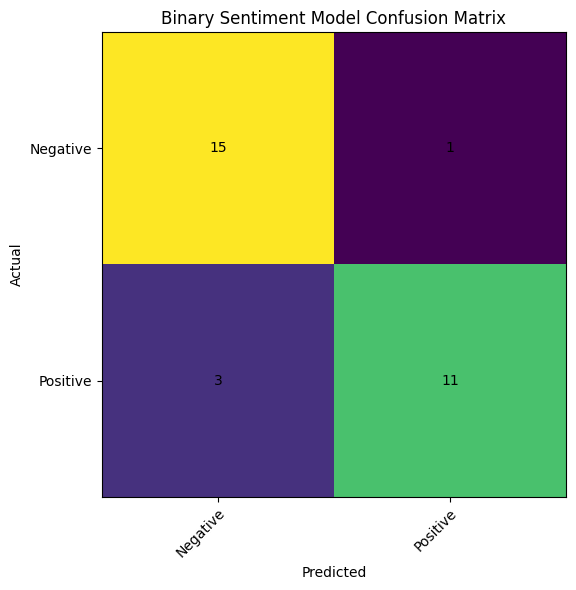

Wrong binary predictions: 4


,actual_label,predicted_label,recommendation,primary_category,secondary_category,mismatch_type,analysis_review
1,Negative,Positive,Not Recommended,Genuine Negative,Low Information,Aligned Negative,this game suck
7,Positive,Negative,Recommended,Genuine Positive,NaN,Aligned Positive,the only thing i was certain was the what ever it was it wanted me gone 10/10
15,Positive,Negative,Recommended,Meme / Joke Review,Low Information,Aligned Positive,the grass was to green so i knew it was a jyn my freind said nah we whent insinde and i had ghostdih go in to a bad place in my body 10/10 experince i would do again
25,Positive,Negative,Recommended,Genuine Positive,NaN,Aligned Positive,played this game since early release days and im still in love with every aspect of the game


Binary wrong predictions saved to:
..\data\processed\binary_wrong_predictions_enriched.csv


In [ ]:
if binary_enriched is not None:
    binary_enriched = add_error_columns(binary_enriched)

    binary_metrics = evaluate_predictions(
        binary_enriched,
        "Binary Sentiment Model"
    )

    binary_wrong = binary_enriched[
        ~binary_enriched["is_correct"]
    ].copy()

    print("Wrong binary predictions:", len(binary_wrong))

    display(
        binary_wrong[
            [
                "actual_label",
                "predicted_label",
                "recommendation",
                "primary_category",
                "secondary_category",
                "mismatch_type",
                "analysis_review"
            ]
        ].head(20)
    )

    binary_wrong.to_csv(
        BINARY_WRONG_OUTPUT_PATH,
        index=False
    )

    print("Binary wrong predictions saved to:")
    print(BINARY_WRONG_OUTPUT_PATH)
else:
    binary_metrics = None
    binary_wrong = pd.DataFrame()
    print("No binary prediction file found. Skipping binary error analysis.")

## 6. Multiclass Model Error Analysis

The multiclass model predicts:

```text
Positive
Negative
Mixed
Neutral/Unclear
```

This task is harder because `Mixed` and `Neutral/Unclear` reviews contain less consistent language.

=== Multiclass Sentiment Model ===
Rows: 43
Accuracy: 0.6512
Macro F1: 0.6162

Classification report:
                 precision    recall  f1-score   support

          Mixed       0.30      0.38      0.33         8
       Negative       0.83      0.94      0.88        16
Neutral/Unclear       0.67      0.80      0.73         5
       Positive       0.67      0.43      0.52        14

       accuracy                           0.65        43
      macro avg       0.62      0.64      0.62        43
   weighted avg       0.66      0.65      0.64        43



,Pred Mixed,Pred Negative,Pred Neutral/Unclear,Pred Positive
Actual Mixed,3,2,1,2
Actual Negative,1,15,0,0
Actual Neutral/Unclear,0,0,4,1
Actual Positive,6,1,1,6


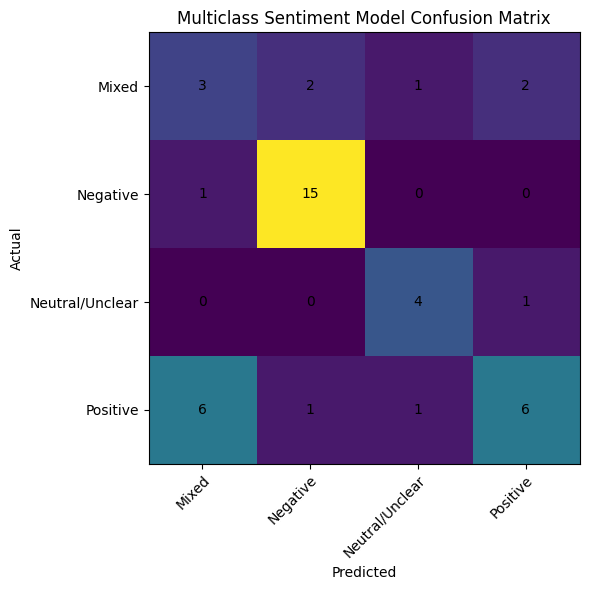

Wrong multiclass predictions: 15


,actual_label,predicted_label,recommendation,primary_category,secondary_category,mismatch_type,analysis_review
1,Positive,Mixed,Recommended,Genuine Positive,Meme / Joke Review,Aligned Positive,I've literally played this game for 66.6 hours. Thats on theme for this game. I'm sad that the next time I play it will roll over but just know this game is incredibly fun and challenging + the community is like no other. I've made several friends just playing this game in public lobbies. ENJOY!
10,Mixed,Negative,Recommended,Mixed Negative,Recommendation Mismatch Candidate,Soft Mismatch: Recommended but Mixed Text,it was good before new update sucks make settings to change things back to original
14,Positive,Mixed,Recommended,Genuine Positive,NaN,Aligned Positive,the only thing i was certain was the what ever it was it wanted me gone 10/10
17,Mixed,Positive,Recommended,Mixed Positive,Bug Complaint,Soft Mismatch: Recommended but Mixed Text,best co-op horror game i have been ever seen to play with friends but this game contains many glitches and bugs that makes users experience a little bit bad and i hope they will fix the bugs and glitches
18,Mixed,Negative,Not Recommended,Mixed Negative,Update Backlash,Soft Mismatch: Not Recommended but Mixed Text,"I still have not let Steam update Phasmo to the latest horrible Alan Wake mess, that's why I think it's still good."
19,Positive,Neutral/Unclear,Recommended,Genuine Positive,NaN,Aligned Positive,saw the ghost got scared and left
23,Neutral/Unclear,Positive,Recommended,Low Information,Low Information,Ambiguous / Low Information,scary?
25,Mixed,Neutral/Unclear,Recommended,Mixed Negative,Non-English / Solo Complaint,Soft Mismatch: Recommended but Mixed Text,в соло не кайф
26,Mixed,Positive,Recommended,Mixed Positive,Positive with Minor Complaint,Soft Mismatch: Recommended but Mixed Text,"Still slaps to this day,yes some customization sucks but remember you play this for the plot so stick to that and you will be satisfied with your purchase. Also works with low spec PC's pretty surprisingly aswell,not incredibly optimized but exceptionally done so far."
30,Negative,Mixed,Not Recommended,Bug / Gameplay Degradation,Performance / Stability Complaint,Aligned Negative,"Great game Idea, but very bad servers and bugs. Settings reset all the time I re-open the game. Random ""lost connection to server"" even tho my internet is perfectly fine, incense doesnt protect sometimes, etc."


Multiclass wrong predictions saved to:
..\data\processed\multiclass_wrong_predictions_enriched.csv


In [ ]:
multiclass_enriched = add_error_columns(multiclass_enriched)

multiclass_metrics = evaluate_predictions(
    multiclass_enriched,
    "Multiclass Sentiment Model"
)

multiclass_wrong = multiclass_enriched[
    ~multiclass_enriched["is_correct"]
].copy()

print("Wrong multiclass predictions:", len(multiclass_wrong))

display(
    multiclass_wrong[
        [
            "actual_label",
            "predicted_label",
            "recommendation",
            "primary_category",
            "secondary_category",
            "mismatch_type",
            "analysis_review"
        ]
    ].head(30)
)

multiclass_wrong.to_csv(
    MULTICLASS_WRONG_OUTPUT_PATH,
    index=False
)

print("Multiclass wrong predictions saved to:")
print(MULTICLASS_WRONG_OUTPUT_PATH)

## 7. Most Common Error Types

This section checks:

```text
Which sentiment classes are most often confused with each other?
```

,error_type,count
0,Correct,28
1,Positive → Mixed,6
2,Mixed → Negative,2
3,Mixed → Positive,2
4,Positive → Neutral/Unclear,1
5,Neutral/Unclear → Positive,1
6,Mixed → Neutral/Unclear,1
7,Negative → Mixed,1
8,Positive → Negative,1


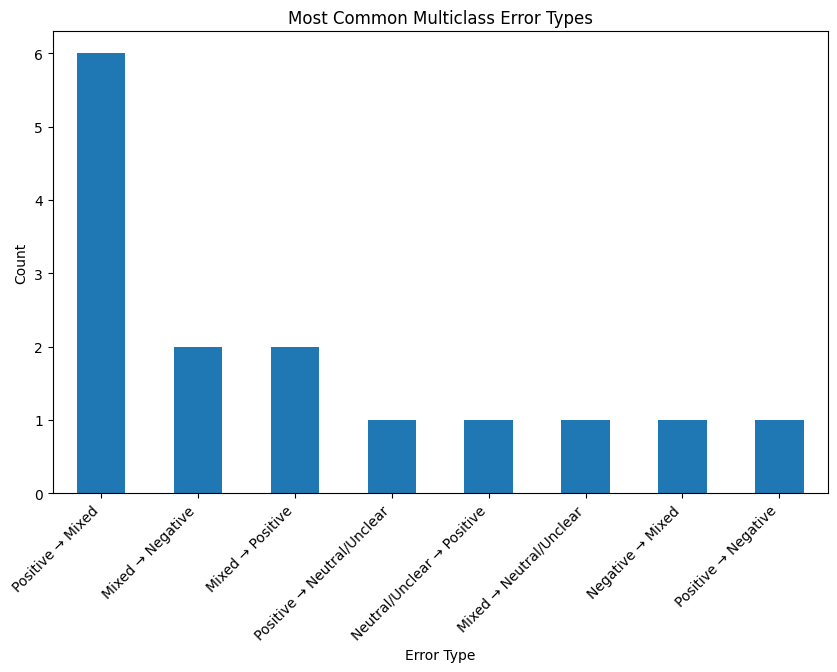

In [ ]:
error_counts = (
    multiclass_enriched["error_type"]
    .value_counts()
    .reset_index()
)

error_counts.columns = ["error_type", "count"]

display(error_counts)

wrong_error_counts = error_counts[
    error_counts["error_type"] != "Correct"
]

if len(wrong_error_counts) > 0:
    wrong_error_counts.plot(
        kind="bar",
        x="error_type",
        y="count",
        legend=False
    )

    plt.title("Most Common Multiclass Error Types")
    plt.xlabel("Error Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.show()
else:
    print("No wrong multiclass predictions.")

## 8. Error Rate by Actual Class

Overall accuracy can hide weak performance on smaller classes. This section compares the error rate for each actual sentiment label.

,actual_label,total_reviews,correct_predictions,wrong_predictions,class_accuracy,error_rate
0,Mixed,8,3,5,0.375,0.625
1,Negative,16,15,1,0.938,0.062
2,Neutral/Unclear,5,4,1,0.800,0.200
3,Positive,14,6,8,0.429,0.571


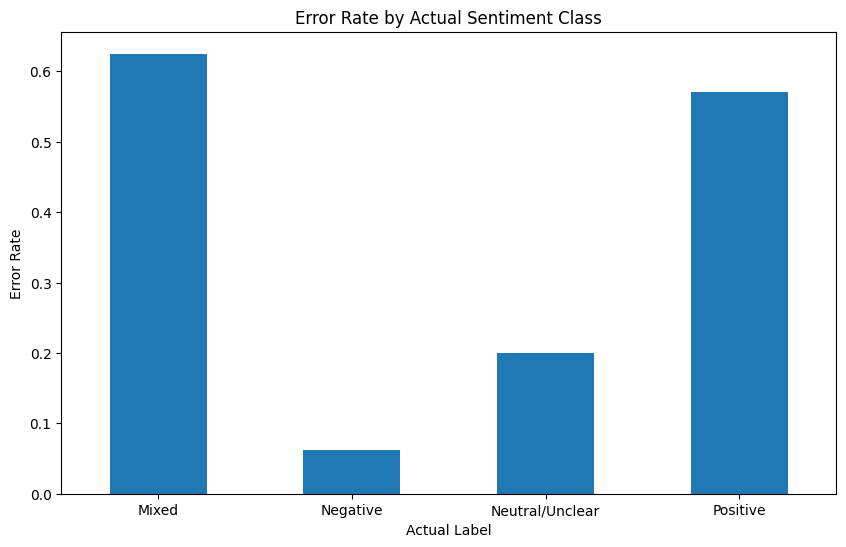

In [ ]:
class_error_summary = (
    multiclass_enriched
    .groupby("actual_label")
    .agg(
        total_reviews=("is_correct", "size"),
        correct_predictions=("is_correct", "sum")
    )
    .reset_index()
)

class_error_summary["wrong_predictions"] = (
    class_error_summary["total_reviews"]
    -
    class_error_summary["correct_predictions"]
)

class_error_summary["class_accuracy"] = (
    class_error_summary["correct_predictions"]
    /
    class_error_summary["total_reviews"]
).round(3)

class_error_summary["error_rate"] = (
    1
    -
    class_error_summary["class_accuracy"]
).round(3)

display(class_error_summary)

class_error_summary.plot(
    kind="bar",
    x="actual_label",
    y="error_rate",
    legend=False
)

plt.title("Error Rate by Actual Sentiment Class")
plt.xlabel("Actual Label")
plt.ylabel("Error Rate")
plt.xticks(rotation=0)
plt.show()

## 9. Error Rate by Review Category

This connects model errors with the manual review categories. The main question is:

```text
Does the model fail more often on Mixed, Meme, Low Information, or Soft Mismatch reviews?
```

,primary_category,total_reviews,correct_predictions,wrong_predictions,error_rate
0,Bug / Gameplay Degradation,1,0,1,1.000
3,Low Information,1,0,1,1.000
5,Mixed Negative,4,1,3,0.750
2,Genuine Positive,14,6,8,0.571
6,Mixed Positive,4,2,2,0.500
7,Mourning,8,8,0,0.000
8,Update Backlash,7,7,0,0.000
4,Meme / Joke Review,3,3,0,0.000
1,Feature Request,1,1,0,0.000


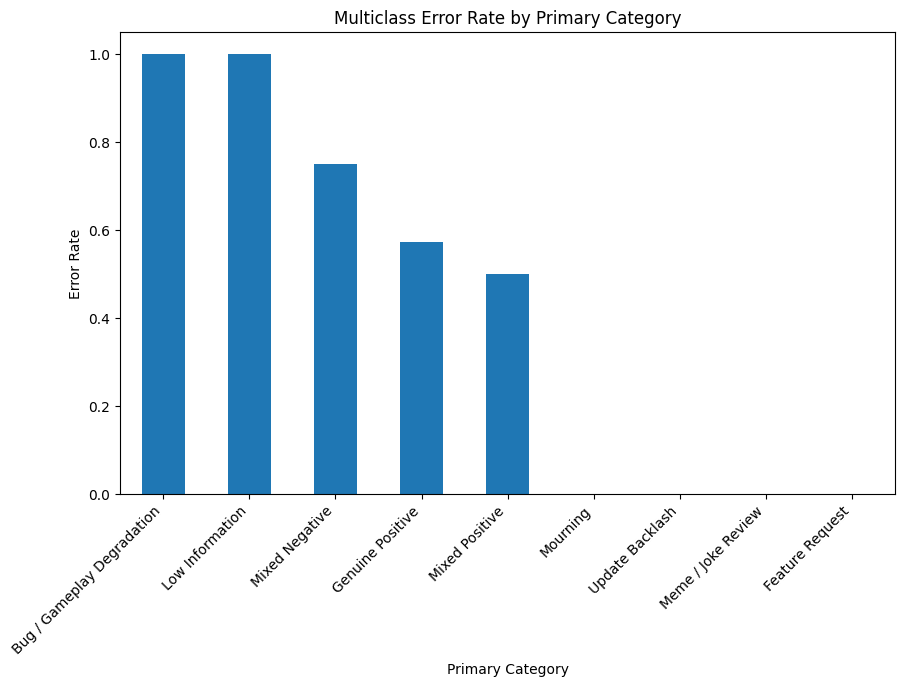

In [ ]:
if "primary_category" in multiclass_enriched.columns:
    category_error_summary = (
        multiclass_enriched
        .groupby("primary_category")
        .agg(
            total_reviews=("is_correct", "size"),
            correct_predictions=("is_correct", "sum")
        )
        .reset_index()
    )

    category_error_summary["wrong_predictions"] = (
        category_error_summary["total_reviews"]
        -
        category_error_summary["correct_predictions"]
    )

    category_error_summary["error_rate"] = (
        category_error_summary["wrong_predictions"]
        /
        category_error_summary["total_reviews"]
    ).round(3)

    category_error_summary = category_error_summary.sort_values(
        by=["error_rate", "total_reviews"],
        ascending=[False, False]
    )

    display(category_error_summary)

    category_error_summary.plot(
        kind="bar",
        x="primary_category",
        y="error_rate",
        legend=False
    )

    plt.title("Multiclass Error Rate by Primary Category")
    plt.xlabel("Primary Category")
    plt.ylabel("Error Rate")
    plt.xticks(rotation=45, ha="right")
    plt.show()
else:
    print("primary_category column not found.")

## 10. Error Rate by Mismatch Type

This section checks whether `Soft Mismatch` and `Ambiguous` reviews are harder to classify. A higher error rate in these groups would support the idea that Steam reviews contain overlapping sentiment signals.

,mismatch_type,total_reviews,correct_predictions,wrong_predictions,error_rate
4,Soft Mismatch: Recommended but Mixed Text,6,2,4,0.667
1,Aligned Positive,14,6,8,0.571
3,Soft Mismatch: Not Recommended but Mixed Text,2,1,1,0.500
2,Ambiguous / Low Information,5,4,1,0.200
0,Aligned Negative,16,15,1,0.062


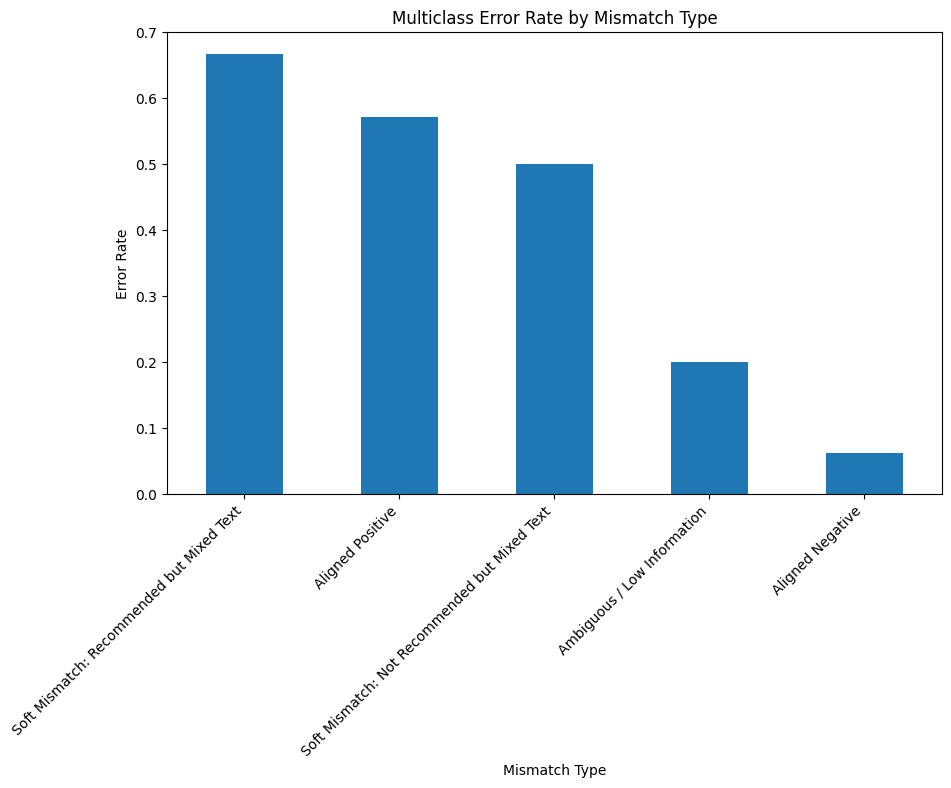

In [ ]:
mismatch_col = None

for candidate_col in ["mismatch_type", "mismatch_type_recomputed"]:
    if candidate_col in multiclass_enriched.columns:
        mismatch_col = candidate_col
        break

if mismatch_col is not None:
    mismatch_error_summary = (
        multiclass_enriched
        .groupby(mismatch_col)
        .agg(
            total_reviews=("is_correct", "size"),
            correct_predictions=("is_correct", "sum")
        )
        .reset_index()
    )

    mismatch_error_summary["wrong_predictions"] = (
        mismatch_error_summary["total_reviews"]
        -
        mismatch_error_summary["correct_predictions"]
    )

    mismatch_error_summary["error_rate"] = (
        mismatch_error_summary["wrong_predictions"]
        /
        mismatch_error_summary["total_reviews"]
    ).round(3)

    mismatch_error_summary = mismatch_error_summary.sort_values(
        by=["error_rate", "total_reviews"],
        ascending=[False, False]
    )

    display(mismatch_error_summary)

    mismatch_error_summary.plot(
        kind="bar",
        x=mismatch_col,
        y="error_rate",
        legend=False
    )

    plt.title("Multiclass Error Rate by Mismatch Type")
    plt.xlabel("Mismatch Type")
    plt.ylabel("Error Rate")
    plt.xticks(rotation=45, ha="right")
    plt.show()
else:
    print("No mismatch type column found.")

## 11. Review Length and Prediction Error

Exploratory question:

```text
Are very short reviews and long mixed reviews more difficult to classify?
```

,count,mean,std,min,25%,50%,75%,max
is_correct,,,,,,,,
False,15.0,36.533333,61.429247,1.0,9.00,17.0,37.0,251.0
True,28.0,67.000000,69.405945,4.0,17.25,34.5,105.0,290.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28608\3371604039.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


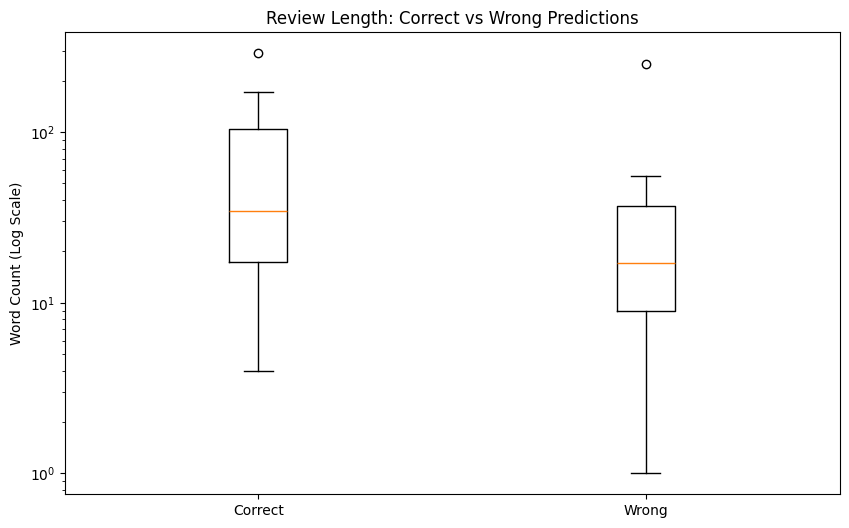

In [ ]:
if "word_count" not in multiclass_enriched.columns:
    multiclass_enriched["word_count"] = (
        multiclass_enriched["analysis_review"]
        .apply(lambda x: len(str(x).split()))
    )

length_summary = (
    multiclass_enriched
    .groupby("is_correct")
    ["word_count"]
    .describe()
)

display(length_summary)

plt.boxplot(
    [
        multiclass_enriched[
            multiclass_enriched["is_correct"]
        ]["word_count"],
        multiclass_enriched[
            ~multiclass_enriched["is_correct"]
        ]["word_count"]
    ],
    labels=["Correct", "Wrong"]
)

plt.yscale("log")
plt.title("Review Length: Correct vs Wrong Predictions")
plt.ylabel("Word Count (Log Scale)")
plt.show()

## 12. Inspect Important Error Groups

This section displays review examples from the error groups that are most useful for interpretation.

In [ ]:
def display_error_group(error_type, n=10):
    subset = multiclass_enriched[
        multiclass_enriched["error_type"] == error_type
    ].copy()

    print(f"Error type: {error_type}")
    print("Rows:", len(subset))

    if len(subset) == 0:
        return

    cols = [
        "actual_label",
        "predicted_label",
        "recommendation",
        "primary_category",
        "secondary_category",
        "mismatch_type",
        "word_count",
        "analysis_review"
    ]

    cols = [col for col in cols if col in subset.columns]

    display(subset[cols].head(n))


important_errors = [
    "Positive → Mixed",
    "Mixed → Positive",
    "Mixed → Negative",
    "Negative → Mixed",
    "Neutral/Unclear → Positive",
    "Positive → Negative"
]

for error in important_errors:
    display_error_group(error, n=8)

Error type: Positive → Mixed
Rows: 6


,actual_label,predicted_label,recommendation,primary_category,secondary_category,mismatch_type,word_count,analysis_review
1,Positive,Mixed,Recommended,Genuine Positive,Meme / Joke Review,Aligned Positive,55,I've literally played this game for 66.6 hours. Thats on theme for this game. I'm sad that the next time I play it will roll over but just know this game is incredibly fun and challenging + the community is like no other. I've made several friends just playing this game in public lobbies. ENJOY!
14,Positive,Mixed,Recommended,Genuine Positive,NaN,Aligned Positive,17,the only thing i was certain was the what ever it was it wanted me gone 10/10
32,Positive,Mixed,Recommended,Genuine Positive,NaN,Aligned Positive,11,i just think its a good game but hard too play
35,Positive,Mixed,Recommended,Genuine Positive,Meme / Joke Review,Aligned Positive,251,"Phasmophobia is exactly the kind of ghost-hunting chaos I want. The problem is that I have no friends to play it with. Which is rude, because this game is clearly built for group panic. I want to walk into a haunted house with a flashlight, a dream, and the confidence of someone who has watched ..."
38,Positive,Mixed,Recommended,Genuine Positive,NaN,Aligned Positive,16,it is a great game to play and really gives the horror vibe while ghost hunting
41,Positive,Mixed,Recommended,Genuine Positive,Low Information,Aligned Positive,5,Great game and great devs.


Error type: Mixed → Positive
Rows: 2


,actual_label,predicted_label,recommendation,primary_category,secondary_category,mismatch_type,word_count,analysis_review
17,Mixed,Positive,Recommended,Mixed Positive,Bug Complaint,Soft Mismatch: Recommended but Mixed Text,39,best co-op horror game i have been ever seen to play with friends but this game contains many glitches and bugs that makes users experience a little bit bad and i hope they will fix the bugs and glitches
26,Mixed,Positive,Recommended,Mixed Positive,Positive with Minor Complaint,Soft Mismatch: Recommended but Mixed Text,44,"Still slaps to this day,yes some customization sucks but remember you play this for the plot so stick to that and you will be satisfied with your purchase. Also works with low spec PC's pretty surprisingly aswell,not incredibly optimized but exceptionally done so far."


Error type: Mixed → Negative
Rows: 2


...

,actual_label,predicted_label,recommendation,primary_category,secondary_category,mismatch_type,word_count,analysis_review
30,Negative,Mixed,Not Recommended,Bug / Gameplay Degradation,Performance / Stability Complaint,Aligned Negative,35,"Great game Idea, but very bad servers and bugs. Settings reset all the time I re-open the game. Random ""lost connection to server"" even tho my internet is perfectly fine, incense doesnt protect sometimes, etc."


Error type: Neutral/Unclear → Positive
Rows: 1


,actual_label,predicted_label,recommendation,primary_category,secondary_category,mismatch_type,word_count,analysis_review
23,Neutral/Unclear,Positive,Recommended,Low Information,Low Information,Ambiguous / Low Information,1,scary?


Error type: Positive → Negative
Rows: 1


,actual_label,predicted_label,recommendation,primary_category,secondary_category,mismatch_type,word_count,analysis_review
42,Positive,Negative,Recommended,Genuine Positive,Developer Praise,Aligned Positive,26,phasmophobia is a fairly well made game where the devs seem to somewhat care about the comunity and have contiunously added new content throughout the years


## 13. Build Dashboard Error Examples

The dashboard dataset keeps representative error examples rather than every wrong prediction.

This output can be used for:

```text
dashboard tooltips
report examples
portfolio discussion
```

In [ ]:
dashboard_examples = multiclass_wrong.copy()

dashboard_columns = [
    "actual_label",
    "predicted_label",
    "error_type",
    "recommendation",
    "primary_category",
    "secondary_category",
    "mismatch_type",
    "annotation_notes",
    "word_count",
    "helpful_count",
    "funny_count",
    "analysis_review"
]

dashboard_columns = [
    col for col in dashboard_columns
    if col in dashboard_examples.columns
]

dashboard_examples = dashboard_examples[dashboard_columns].copy()

priority_order = {
    "Positive → Mixed": 1,
    "Mixed → Positive": 2,
    "Mixed → Negative": 3,
    "Negative → Mixed": 4,
    "Neutral/Unclear → Positive": 5
}

dashboard_examples["error_priority"] = (
    dashboard_examples["error_type"]
    .map(priority_order)
    .fillna(99)
)

if "word_count" not in dashboard_examples.columns:
    dashboard_examples["word_count"] = (
        dashboard_examples["analysis_review"]
        .apply(lambda x: len(str(x).split()))
    )

dashboard_examples = dashboard_examples.sort_values(
    by=["error_priority", "word_count"],
    ascending=[True, False]
)

dashboard_examples.to_csv(
    DASHBOARD_EXAMPLES_OUTPUT_PATH,
    index=False
)

print("Dashboard/report error examples saved to:")
print(DASHBOARD_EXAMPLES_OUTPUT_PATH)

display(dashboard_examples.head(20))

Dashboard/report error examples saved to:
..\data\processed\dashboard_error_examples.csv


,actual_label,predicted_label,error_type,recommendation,primary_category,secondary_category,mismatch_type,annotation_notes,word_count,helpful_count,funny_count,analysis_review,error_priority
35,Positive,Mixed,Positive → Mixed,Recommended,Genuine Positive,Meme / Joke Review,Aligned Positive,Long comedic review but overall clearly praises the game.,251,0,0,"Phasmophobia is exactly the kind of ghost-hunting chaos I want. The problem is that I have no friends to play it with. Which is rude, because this game is clearly built for group panic. I want to walk into a haunted house with a flashlight, a dream, and the confidence of someone who has watched ...",1.0
1,Positive,Mixed,Positive → Mixed,Recommended,Genuine Positive,Meme / Joke Review,Aligned Positive,"Positive overall; sadness is about playtime moving past 66.6 hours, not game dissatisfaction.",55,0,0,I've literally played this game for 66.6 hours. Thats on theme for this game. I'm sad that the next time I play it will roll over but just know this game is incredibly fun and challenging + the community is like no other. I've made several friends just playing this game in public lobbies. ENJOY!,1.0
14,Positive,Mixed,Positive → Mixed,Recommended,Genuine Positive,NaN,Aligned Positive,Straightforward positive Recommended review.,17,0,0,the only thing i was certain was the what ever it was it wanted me gone 10/10,1.0
38,Positive,Mixed,Positive → Mixed,Recommended,Genuine Positive,NaN,Aligned Positive,Straightforward positive Recommended review.,16,0,0,it is a great game to play and really gives the horror vibe while ghost hunting,1.0
32,Positive,Mixed,Positive → Mixed,Recommended,Genuine Positive,NaN,Aligned Positive,Straightforward positive Recommended review.,11,0,0,i just think its a good game but hard too play,1.0
41,Positive,Mixed,Positive → Mixed,Recommended,Genuine Positive,Low Information,Aligned Positive,Positive.,5,0,0,Great game and great devs.,1.0
26,Mixed,Positive,Mixed → Positive,Recommended,Mixed Positive,Positive with Minor Complaint,Soft Mismatch: Recommended but Mixed Text,Still recommends the game while acknowledging customization issues.,44,0,0,"Still slaps to this day,yes some customization sucks but remember you play this for the plot so stick to that and you will be satisfied with your purchase. Also works with low spec PC's pretty surprisingly aswell,not incredibly optimized but exceptionally done so far.",2.0
17,Mixed,Positive,Mixed → Positive,Recommended,Mixed Positive,Bug Complaint,Soft Mismatch: Recommended but Mixed Text,Strongly positive overall but bugs/glitches harm experience.,39,0,0,best co-op horror game i have been ever seen to play with friends but this game contains many glitches and bugs that makes users experience a little bit bad and i hope they will fix the bugs and glitches,2.0
18,Mixed,Negative,Mixed → Negative,Not Recommended,Mixed Negative,Update Backlash,Soft Mismatch: Not Recommended but Mixed Text,"Still thinks the older/non-updated version is good, but rejects the latest update.",22,0,0,"I still have not let Steam update Phasmo to the latest horrible Alan Wake mess, that's why I think it's still good.",3.0
10,Mixed,Negative,Mixed → Negative,Recommended,Mixed Negative,Recommendation Mismatch Candidate,Soft Mismatch: Recommended but Mixed Text,Recommended label but says the new update sucks and asks for original settings.,15,0,0,it was good before new update sucks make settings to change things back to original,3.0


## 14. Export Error Analysis Summary

This step exports the main error-analysis metrics to a CSV file.

In [ ]:
summary_rows = []

if binary_enriched is not None and binary_metrics is not None:
    summary_rows.append({
        "analysis_section": "Binary Model",
        "metric": "accuracy",
        "value": round(binary_metrics["accuracy"], 4),
        "interpretation": "Binary Positive/Negative sentiment classification performance."
    })

    summary_rows.append({
        "analysis_section": "Binary Model",
        "metric": "macro_f1",
        "value": round(binary_metrics["macro_f1"], 4),
        "interpretation": "Balanced binary classification performance across Positive and Negative."
    })

    summary_rows.append({
        "analysis_section": "Binary Model",
        "metric": "wrong_predictions",
        "value": int((~binary_enriched["is_correct"]).sum()),
        "interpretation": "Number of wrong binary test predictions."
    })

summary_rows.append({
    "analysis_section": "Multiclass Model",
    "metric": "accuracy",
    "value": round(multiclass_metrics["accuracy"], 4),
    "interpretation": "Overall multiclass sentiment classification performance."
})

summary_rows.append({
    "analysis_section": "Multiclass Model",
    "metric": "macro_f1",
    "value": round(multiclass_metrics["macro_f1"], 4),
    "interpretation": "Balanced multiclass performance across Positive, Negative, Mixed, and Neutral/Unclear."
})

summary_rows.append({
    "analysis_section": "Multiclass Model",
    "metric": "wrong_predictions",
    "value": int((~multiclass_enriched["is_correct"]).sum()),
    "interpretation": "Number of wrong multiclass test predictions."
})

if len(wrong_error_counts) > 0:
    top_error = wrong_error_counts.iloc[0]

    summary_rows.append({
        "analysis_section": "Multiclass Model",
        "metric": "most_common_error_type",
        "value": top_error["error_type"],
        "interpretation": f"Most frequent confusion pattern, occurring {top_error['count']} times."
    })

summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv(
    ERROR_SUMMARY_OUTPUT_PATH,
    index=False
)

print("Error analysis summary saved to:")
print(ERROR_SUMMARY_OUTPUT_PATH)

display(summary_df)

Error analysis summary saved to:
..\data\processed\model_error_analysis_summary.csv


,analysis_section,metric,value,interpretation
0,Binary Model,accuracy,0.8667,Binary Positive/Negative sentiment classification performance.
1,Binary Model,macro_f1,0.8643,Balanced binary classification performance across Positive and Negative.
2,Binary Model,wrong_predictions,4,Number of wrong binary test predictions.
3,Multiclass Model,accuracy,0.6512,Overall multiclass sentiment classification performance.
4,Multiclass Model,macro_f1,0.6162,"Balanced multiclass performance across Positive, Negative, Mixed, and Neutral/Unclear."
5,Multiclass Model,wrong_predictions,15,Number of wrong multiclass test predictions.
6,Multiclass Model,most_common_error_type,Positive → Mixed,"Most frequent confusion pattern, occurring 6 times."


## 15. Interpretation Notes

The final interpretation should focus on the following pattern:

```text
The binary TF-IDF + Logistic Regression model performs reasonably well for clear Positive vs Negative sentiment. This suggests that Steam review text contains learnable polarity signals, especially around positive gameplay terms such as "fun", "scary", and "friends", and negative update-related terms such as "update", "animations", "ruined", "bugs", and "unplayable".

However, the multiclass model performs less consistently, especially on Mixed and Neutral/Unclear reviews. Error analysis shows that many wrong predictions occur when reviews contain both praise and criticism, meme-like wording, low-information text, or positive recommendations with bug/update complaints.

This supports the broader project finding: Steam recommendation labels are useful for coarse polarity, but they do not fully capture the nuance of player sentiment. Recommended reviews can still contain mixed sentiment, jokes, ambiguity, or complaints, which require deeper text analysis beyond the binary Steam label.
```

Next notebook:

```text
07_dashboard_dataset_prep.ipynb
```